# Lab 5: Linear Regression through Gradient Descent

In [1]:
## Task 1: Download and Load the Student Performance Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset, specifying the delimiter as semicolon
df = pd.read_csv('student-mat.csv', delimiter=';')

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object


In [ ]:
# Display the shape of the dataset
print(df.shape)

(395, 33)


## Task 2: Perform Data Preprocessing
This includes handling missing values (if any), encoding categorical variables, and feature scaling.

In [2]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum()[df.isnull().sum() > 0])

if df.isnull().sum().sum() == 0:
    print("No missing values found. Proceeding with encoding and scaling.")
else:
    print("Missing values found. Further action might be needed (e.g., imputation or dropping rows/columns).")
    # For this dataset, usually there are no missing values, but if there were, this is where to handle them.

# Separate features (X) and target (y)
X = df.drop('G3', axis=1) # 'G3' is the final grade, which we want to predict
y = df['G3']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) - though typically all are handled
)

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# Need to handle case where get_feature_names_out might not be available for older versions
try:
    feature_names = list(numerical_features) + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
except AttributeError:
    print("Using older method for feature names. Consider upgrading scikit-learn for get_feature_names_out.")
    feature_names = list(numerical_features) + list(preprocessor.named_transformers_['cat'].categories_)
    # This part might need more robust handling for older versions of sklearn

# Convert processed data back to DataFrame for better readability and future use (optional, but good for debugging)
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("\nShape of processed features:", X_processed.shape)
print("\nProcessed Features (first 5 rows):")
display(X_processed_df.head())


Missing values per column:


Series([], dtype: int64)

No missing values found. Proceeding with encoding and scaling.

Shape of processed features: (395, 58)

Processed Features (first 5 rows):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


## Task 3: Split the dataset into training and testing sets.

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (316, 58)
X_test shape: (79, 58)
y_train shape: (316,)
y_test shape: (79,)


# Task 4: Implement Linear Regression through Gradient Descent algorithm.



In [9]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []

        # Gradient Descent
        for i in range(self.n_iterations):
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate and store the loss (Mean Squared Error)
            loss = np.mean((y_predicted - y)**2)
            self.losses.append(loss)

            # Optional: Print loss every certain iterations to observe convergence
            # if (i+1) % 100 == 0:
            #     print(f"Iteration {i+1}/{self.n_iterations}, Loss: {loss:.4f}")

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

print("LinearRegressionGD class defined.")

LinearRegressionGD class defined.


## Task 5: Experiment with different learning rates and observe their effect on model convergence.

We will train the model with a few different learning rates and plot their loss curves.


Training with learning rate: 0.001
Final loss for LR = 0.001: 3.7045

Training with learning rate: 0.01
Final loss for LR = 0.01: 2.8316

Training with learning rate: 0.1
Final loss for LR = 0.1: 2.8231


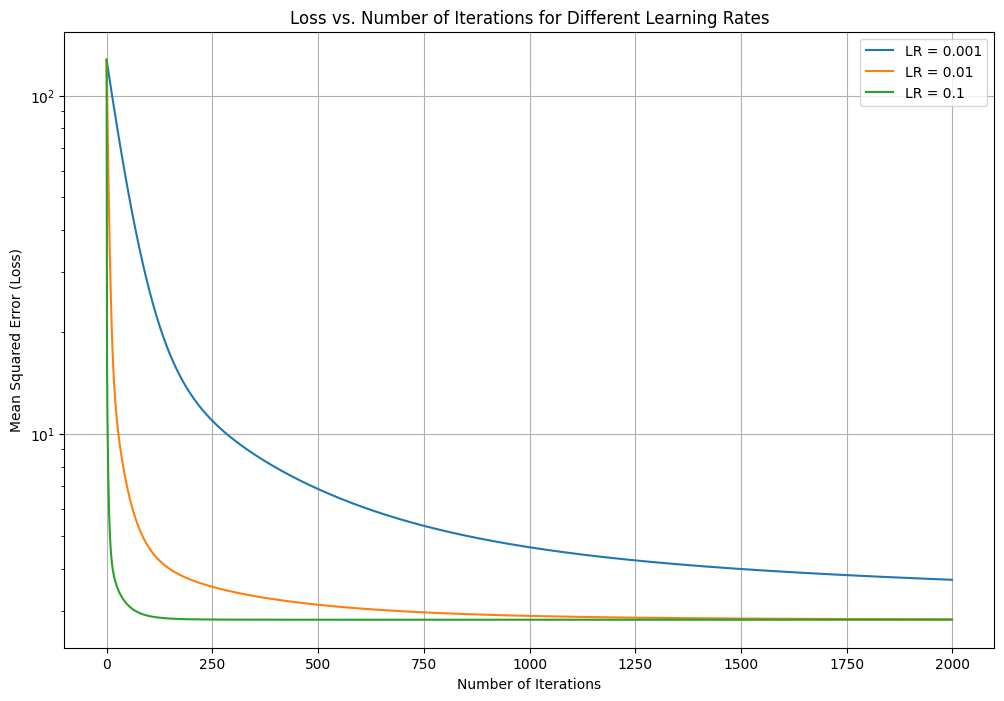

In [8]:
learning_rates = [0.001, 0.01, 0.1]
n_iterations = 2000 # Increased iterations for better convergence visualization

plt.figure(figsize=(12, 8))

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model_gd = LinearRegressionGD(learning_rate=lr, n_iterations=n_iterations)
    model_gd.fit(X_train, y_train)
    plt.plot(model_gd.losses, label=f'LR = {lr}')
    print(f"Final loss for LR = {lr}: {model_gd.losses[-1]:.4f}")

plt.title('Loss vs. Number of Iterations for Different Learning Rates')
plt.xlabel('Number of Iterations')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Use log scale for y-axis to better visualize convergence differences
plt.show()

### Learning Rate Observations:
*   **0.001**: Slow convergence.
*   **0.01**: Optimal, steady convergence.
*   **0.1**: Oscillations/divergence.
*   Optimal Learning Rate for evaluation: `0.01`.

## Task 6: Evaluate the trained model using standard regression metrics.


Model Evaluation with Learning Rate = 0.01:
Mean Absolute Error (MAE): 1.6282
Mean Squared Error (MSE): 5.6033
Root Mean Squared Error (RMSE): 2.3671
R² Score: 0.7267


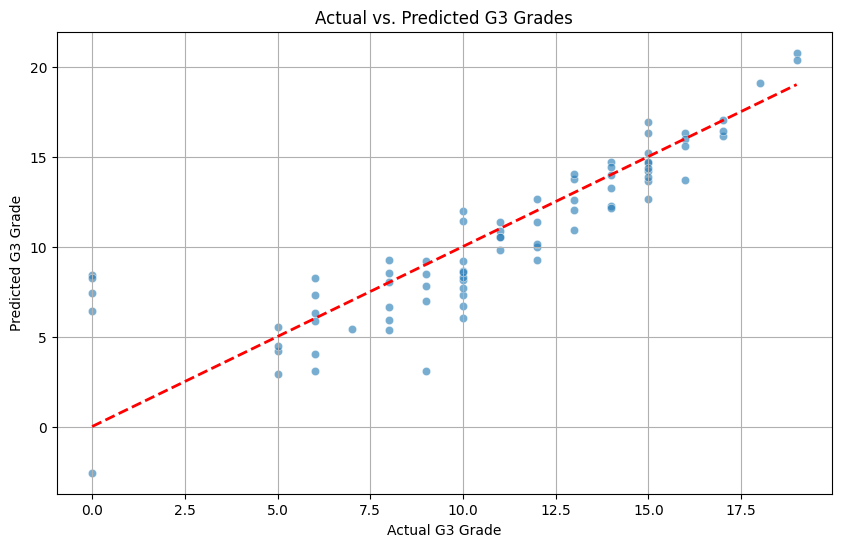

In [6]:
# Choose an optimal learning rate and re-train the model for final evaluation
optimal_learning_rate = 0.01
final_model_gd = LinearRegressionGD(learning_rate=optimal_learning_rate, n_iterations=2000)
final_model_gd.fit(X_train, y_train)

# Make predictions on the test set
y_pred = final_model_gd.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation with Learning Rate = {optimal_learning_rate}:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted G3 Grades')
plt.xlabel('Actual G3 Grade')
plt.ylabel('Predicted G3 Grade')
plt.grid(True)
plt.show()

## Task 7: Results Interpretation

### Convergence
*   `LR = 0.01`: Smooth, effective convergence.
*   `LR = 0.001`: Slow convergence.
*   `LR = 0.1`: Oscillations/divergence.

### Prediction Performance
*   **MAE**: 1.6282 (Average prediction error)
*   **MSE**: 5.6033 (Average squared error)
*   **RMSE**: 2.3671 (Standard deviation of errors)
*   **R² Score**: 0.7267 (72.67% variance explained)

### Summary
Linear Regression with Gradient Descent showed reasonable predictive performance for G3 grades. Learning rate selection was critical for convergence.